In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Adicionar o caminho para o diretório src
sys.path.append(os.path.abspath('../src'))

# Importar as tuas classes de raiz
from utils import prepare_text_data
from neuralnet import NeuralNetwork
from layers import DenseLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy

In [11]:
# Carregar o dataset real
df = pd.read_csv('../data/dataset.csv').dropna()

# Extrair listas
textos = df['text'].tolist()
labels = df['label'].tolist()

# Preparar dados: TF-IDF (500 colunas) e One-Hot Encoding para 5 classes
X_train, Y_train, X_val, Y_val, X_test, Y_test, vectorizer, encoder = prepare_text_data(
    textos, 
    labels, 
    max_features=500,  
    test_size=0.2,     
    val_size=0.1,      
    use_stratify=True 
)

print(f"✅ Setup Concluído!")
print(f"Input Dim: {X_train.shape[1]} | Classes: {encoder.categories_[0]}")

✅ Setup Concluído!
Input Dim: 500 | Classes: ['human' 'openai']


In [12]:
# Definir dimensões
input_dim = X_train.shape[1] 
output_dim = Y_train.shape[1] # Deve ser 5

# Montar a rede
nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())

# Camada 1: 500 -> 128
nn.add(DenseLayer(input_shape=input_dim, n_units=128, learning_rate=0.01, momentum=0.9))
nn.add(ReLUActivation())

# Camada 2: 128 -> 64
nn.add(DenseLayer(input_shape=128, n_units=64, learning_rate=0.01, momentum=0.9))
nn.add(ReLUActivation())

# Camada 3: 64 -> 5 (Saída)
nn.add(DenseLayer(input_shape=64, n_units=output_dim, learning_rate=0.01, momentum=0.9))
nn.add(SoftmaxActivation())

print("Rede Neuronal montada com sucesso!")

Rede Neuronal montada com sucesso!


In [13]:
epochs = 50          
batch_size = 32      

print("A iniciar o treino no Numpy...")
nn.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=True)

A iniciar o treino no Numpy...
Epoch 1/50 | Loss: 0.4353
Epoch 11/50 | Loss: 0.3880
Epoch 21/50 | Loss: 0.3879
Epoch 31/50 | Loss: 0.3879
Epoch 41/50 | Loss: 0.3878
Epoch 50/50 | Loss: 0.3876


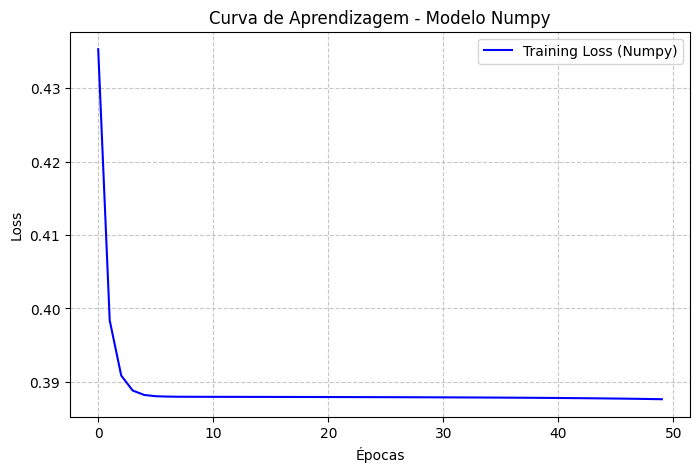

Resultados Finais (Numpy)
Teste Loss: 0.3878
Teste Accuracy: 86.91%


In [ ]:
# 1. Desenhar a curva de Loss
plt.figure(figsize=(8, 5))
plt.plot(nn.history['loss'], label='Training Loss (Numpy)', color='blue')
plt.title('Curva de Aprendizagem - Modelo Numpy')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 2. Avaliar nos dados de teste
test_loss, test_acc = nn.evaluate(X_test, Y_test)
print(f"Resultados do Modelo Numpy:")
print(f"Teste Loss: {test_loss:.4f}")
print(f"Teste Accuracy: {test_acc*100:.2f}%")